# House Price Prediction — Internship Project Week 1

**Project:** Predicting house prices using property features (size, rooms, location-related amenities, age proxies) and identifying which features influence price most strongly.

**Dataset:** Housing Prices Dataset (Kaggle) — 545 records, 13 columns.

## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

## Task 1 — Data Loading & Exploration

Load the dataset, inspect its shape, preview the first 10 rows, identify the target vs. feature columns, and check for missing values.

In [2]:
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 545
Number of columns: 13


**Target column:** `price` — this is what we are trying to predict.

**Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus` — these describe the property and are used to predict the price.

Note: this dataset does not contain a separate "age of property" column, but it does include `stories`, `parking`, and several yes/no amenity flags, which we use as the available proxies for property characteristics.

In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

There are **no missing values** in any column of this dataset.

## Task 2 — Data Cleaning

Since there are no missing values, the cleaning step focuses on: removing duplicate rows (if any), and converting categorical yes/no and furnishing-status columns into numeric form.

In [5]:
print(f"Duplicate rows before cleaning: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows before cleaning: 0
Shape after removing duplicates: (545, 13)


In [6]:
# Convert binary yes/no columns into 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [7]:
# One-hot encode the multi-category 'furnishingstatus' column
df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
print("Final columns used for modeling:")
print(list(df_encoded.columns))

Final columns used for modeling:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


All columns are meaningful predictors of price (size, rooms, amenities, and location/furnishing indicators), so every column is retained for modeling — none were dropped as irrelevant.

## Task 3 — Model Building

Split the data 80/20 into train/test sets, then train and evaluate two models: Linear Regression and Random Forest Regressor.

In [8]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 436 rows
Test set size: 109 rows


### Model 1: Linear Regression

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print(f"MAE:  {mae_lr:,.2f}")
print(f"RMSE: {rmse_lr:,.2f}")
print(f"R2 Score: {r2_lr:.4f}")

Linear Regression Performance
MAE:  970,043.40
RMSE: 1,324,506.96
R2 Score: 0.6529


### Model 2: Random Forest Regressor

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print(f"MAE:  {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Random Forest Performance
MAE:  1,022,560.05
RMSE: 1,401,496.84
R2 Score: 0.6114


In [11]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


**Comparison:** On this dataset, Linear Regression slightly outperformed Random Forest on all three metrics (lower MAE, lower RMSE, higher R²). This is a useful reminder that more complex models don't automatically win — with only ~545 rows and mostly linear-ish relationships (bigger area → higher price), a simple linear model generalizes at least as well as a more flexible one, which can overfit on small data.

## Task 4 — Visualization

Three charts: the price distribution, a correlation heatmap, and a custom chart (Actual vs. Predicted price scatter plot).

### Chart 1: Distribution of House Prices

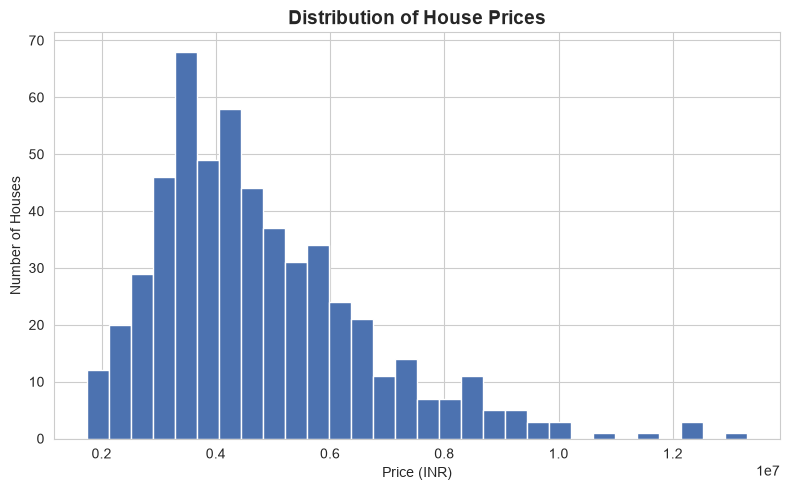

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30, color='#4C72B0', edgecolor='white')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

The price distribution is **right-skewed** — most houses cluster between roughly ₹3M–₹6M, with a long tail of higher-priced properties extending up to ₹13.3M.

### Chart 2: Correlation Heatmap

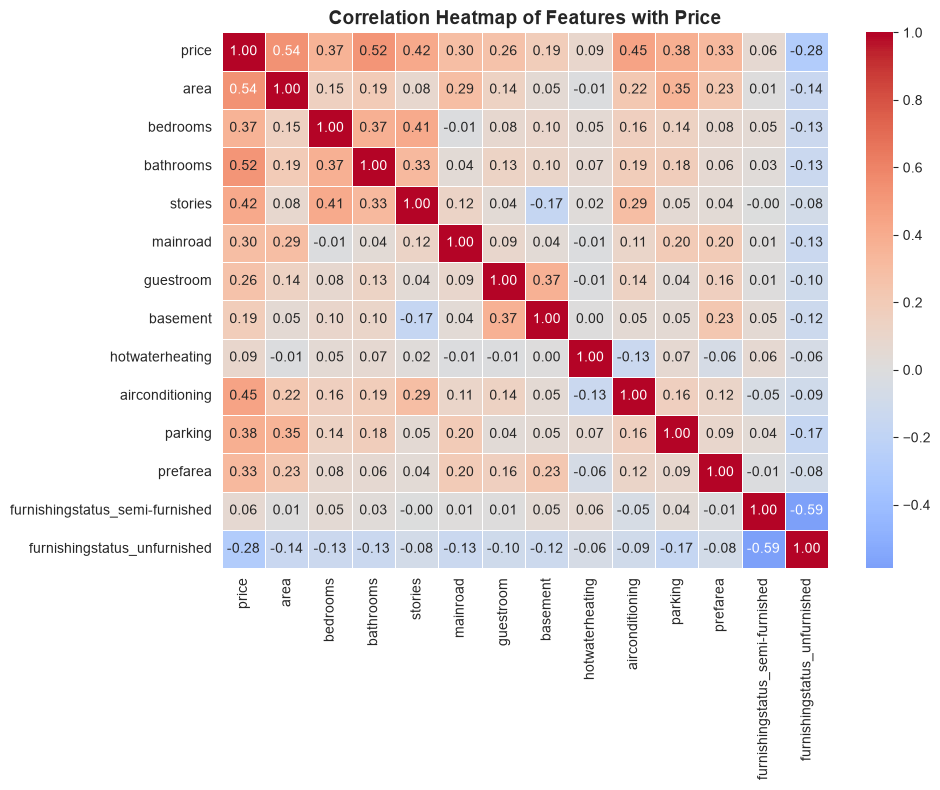

In [13]:
plt.figure(figsize=(10,8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Features with Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

In [14]:
df_encoded.corr()['price'].sort_values(ascending=False)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

`area` and `bathrooms` show the strongest positive correlation with price, followed by `airconditioning` and `stories`. Being `unfurnished` correlates negatively with price.

### Chart 3: Actual vs. Predicted Price (Linear Regression)

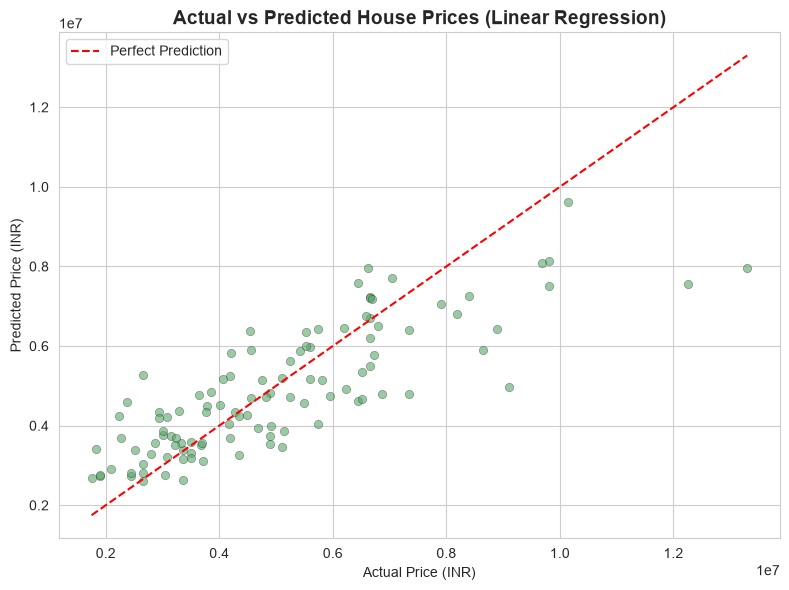

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='#55A868', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted House Prices (Linear Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

Points falling close to the red dashed line represent accurate predictions. The model tracks the overall trend reasonably well but tends to underpredict some of the highest-priced homes, consistent with the right-skewed price distribution seen in Chart 1.

## Task 5 — Insights & Summary

>The three factors that appeared to have the greatest influence on house prices according to correlation and feature importance were: the area of the home, the number of bathrooms in the home, and whether or not the home has air conditioning; with the area representing the largest influence by far. The Linear Regression model used to predict the house price was relatively accurate by predicting approximately 65% of the variability in price (R² = 0.653), and having an average predicted error of about ₹970,000, which you can use as a ballpark figure to help you set the price for your house, but it cannot be relied on for determining an actual list price. One thing that surprised me when I analyzed these results, was the fact that the Linear Regression model was able to outperform the Random Forest model (R² = 0.653 vs R² = 0.611); I had assumed that the Random Forest would be the better predictor because it was more complex than the Linear Regression model. Another interesting finding was that having air conditioning had a stronger correlation to price than having a certain number of bedrooms. Based on these findings, I would suggest that if a real estate agent were trying to sell their clients home, they should market it as being priced higher because it has more square footage, has more bathrooms, and has air conditioning, than if the home only had a certain number of bedrooms.
